# Detecting Topic Merges and Splits in Dynamic Political Conversations

Cláudia Oliveira 

Supervisor - Prof. Dr. Álvaro Figueira

Faculty of Science, University of Porto

Total documents: 2625
Categories: {'talk.politics.misc', 'talk.politics.guns', 'talk.politics.mideast'}
TF-IDF shape: (2625, 2671)


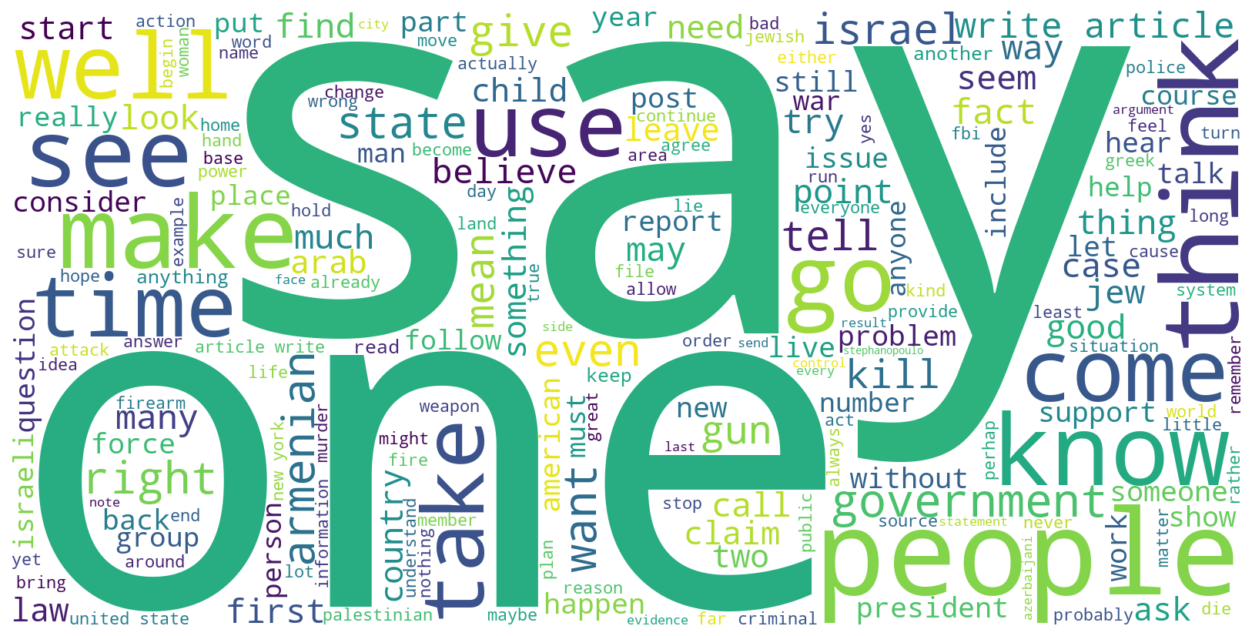

In [ ]:
import os
import re
import pandas as pd
from nltk.corpus import stopwords
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize
import spacy

# nltk.download('punkt')
# nltk.download('stopwords')

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

import os
os.chdir("../..")

# ----------------------
# 1. Function to load political documents
# ----------------------
def load_politics_documents(base_path):
    texts = []
    labels = []
    
    for folder in os.listdir(base_path):
        if "politics" in folder.lower():
            folder_path = os.path.join(base_path, folder)

            for filename in os.listdir(folder_path):
                file_path = os.path.join(folder_path, filename)
                if not os.path.isfile(file_path):
                    continue

                with open(file_path, "r", encoding="latin1", errors="ignore") as f:
                    text = f.read()

                texts.append(text)
                labels.append(folder)

    return texts, labels


# ----------------------
# 2. Load train + test datasets
# ----------------------
train_path = "datasets/20news-bydate-train"
test_path  = "datasets/20news-bydate-test"

train_texts, train_labels = load_politics_documents(train_path)
test_texts, test_labels = load_politics_documents(test_path)

all_texts = train_texts + test_texts
all_labels = train_labels + test_labels

print("Total documents:", len(all_texts))
print("Categories:", set(all_labels))


# ----------------------
# 3. Preprocessing with stopwords + lemmatization (BERTopic)
# ----------------------
stop_words = set(stopwords.words("english"))

def preprocess(text):
    text = text.lower()
    
    text = re.sub(r"(?s)^.*?\n\n", "", text)
    
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r'\S+@\S+', '', text)
    
    text = re.sub(r"[^a-z\s]", " ", text)
    
    text = re.sub(r"\s+", " ", text).strip()

    tokens = [word for word in text.split() if word not in stop_words and len(word) > 2]

    doc = nlp(" ".join(tokens))
    lemmatized = [token.lemma_ for token in doc]

    return " ".join(lemmatized)

clean_texts = [preprocess(t) for t in all_texts]


# ----------------------
# 4. Minimal preprocessing for Top2Vec 
# ----------------------
def preprocess_top2vec(text):
    text = text.lower()
    text = re.sub(r"(?s)^.*?\n\n", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

top2vec_texts = [preprocess_top2vec(t) for t in all_texts]


# ----------------------
# 5. Create TF-IDF matrix 
# ----------------------
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_df=0.6,
    min_df=20,
    max_features=15000,
)

tfidf_matrix = vectorizer.fit_transform(clean_texts)
print("TF-IDF shape:", tfidf_matrix.shape)


# ----------------------
# 6. Create final dataset
# ----------------------
df = pd.DataFrame({
    "raw_text": all_texts,
    "clean_text": clean_texts,
    "top2vec_text": top2vec_texts,
    "label": all_labels
})

df.head()


# ----------------------
# 7. WordCloud using clean_text
# ----------------------
all_words = " ".join(clean_texts)

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(16,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()


# ----------------------
# 8. Tokenization
# ----------------------
df['tokens'] = df['clean_text'].apply(word_tokenize)


In [13]:
df

,raw_text,clean_text,top2vec_text,label,tokens
0,From: manes@magpie.linknet.com (Steve Manes)\n...,write article steve manes write rate per capit...,hambidge@bms.com wrote: : in article <c4psog.c...,talk.politics.guns,"[write, article, steve, manes, write, rate, pe..."
1,From: manes@magpie.linknet.com (Steve Manes)\n...,jim arras write last year suffer almost wrongf...,jim de arras (jmd@cube.handheld.com) wrote: : ...,talk.politics.guns,"[jim, arras, write, last, year, suffer, almost..."
2,From: manes@magpie.linknet.com (Steve Manes)\n...,steve kao write frank crary post sure differen...,steve kao (k@hprnd.rose.hp.com) wrote: : frank...,talk.politics.guns,"[steve, kao, write, frank, crary, post, sure, ..."
3,From: rats@cbnewsc.cb.att.com (Morris the Cat)...,open letter paul blackman research coordinator...,----------------------------------------------...,talk.politics.guns,"[open, letter, paul, blackman, research, coord..."
4,From: cower@csli.stanford.edu (Richard Cower)\...,atf agent interview street story report raid i...,"the atf agent interviewed on ""street stories"" ...",talk.politics.guns,"[atf, agent, interview, street, story, report,..."
...,...,...,...,...,...
2620,From: cramer@optilink.COM (Clayton Cramer)\nSu...,article quoc tuan pham write anyone notice cli...,in article <93apr22.234553edt.47633@neat.cs.to...,talk.politics.misc,"[article, quoc, tuan, pham, write, anyone, not..."
2621,From: cramer@optilink.COM (Clayton Cramer)\nSu...,article tree schnopia write clayton cramer wri...,in article <1993apr22.165002.18208@galileo.cc....,talk.politics.misc,"[article, tree, schnopia, write, clayton, cram..."
2622,From: cramer@optilink.COM (Clayton Cramer)\nSu...,article tree schnopia write clayton cramer wri...,in article <1993apr22.165729.18393@galileo.cc....,talk.politics.misc,"[article, tree, schnopia, write, clayton, cram..."
2623,From: V2110A@VM.TEMPLE.EDU (Richard Hoenes)\nS...,initial gun battle day come peacefully high pr...,"after the initial gun battle was over, they ha...",talk.politics.misc,"[initial, gun, battle, day, come, peacefully, ..."


In [14]:
df.to_csv("datasets/20news.csv", index=False)